## AI Tools for Public Safety

### Requirements
- "pip install pandas scikit-learn matplotlib seaborn xgboost"in a terminal outside of the notebook
- Dataset downloaded (included in the GitHub Repository)

### Instructions
- Clear all Cell Outputs before starting.
- Run each cell in order, skipping the first cell. 
- Change the read "df = pd.read_csv.." line to match the file path of the downloaded csv.
  (Right click and copy file path, pasting over the original path in the paranthesis)




### First cell
No need to run this first cell, just shows how the original dataset was filtered to only EMS incidents.

In [ ]:
import pandas as pd

df = pd.read_csv('911_ems_only.csv')
ems_df = df[df['title'].str.startswith('EMS')]

print(f'Original rows: {len(df)}')
print(f'EMS only rows: {len(ems_df)}')

### First step (Importing all Required Libraries)
- Imports all needed libraries for data visualization and processing

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score)

print("All libraries loaded successfully.")


All libraries loaded successfully.


## Second Step (Importing Database)
- Imports the database, should be downloaded from the GitHub Repository already filtered.

In [56]:
# Replace '911_ems_only.csv' with your filepath.
df = pd.read_csv('911_ems_only.csv')

# Create table
print(f'Dataset shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nFirst 5 rows:')

# Show first 5 rows to ensure correct formatting
df.head()


Dataset shape: (332692, 9)

Columns: ['lat', 'lng', 'desc', 'zip', 'title', 'timeStamp', 'twp', 'addr', 'e']

First 5 rows:


,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:10:52,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:29:21,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 16:47:36,NORRISTOWN,AIRY ST & SWEDE ST,1
3,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 16:56:52,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1
4,40.253473,-75.283245,CANNON AVE & W 9TH ST; LANSDALE; Station 345;...,19446.0,EMS: HEAD INJURY,2015-12-10 15:39:04,LANSDALE,CANNON AVE & W 9TH ST,1


In [62]:
# Check for any missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
lat              0
lng              0
desc             0
zip          27837
title            0
timeStamp        0
twp            212
addr             0
e                0
dtype: int64


### Step 3 (Vectorization)
- Parse Timestamps into hours and months
- Isolate call type

In [63]:
# Parse timestamps into hours and months for analysis use
df['timeStamp'] = pd.to_datetime(df['timeStamp'])
df['hour']  = df['timeStamp'].dt.hour
df['month'] = df['timeStamp'].dt.month

# First five rows to ensure it was parsed correctly
print("Timestamps extracted.")
df[['timeStamp', 'hour', 'month']].head()

Timestamps extracted.


,timeStamp,hour,month
0,2015-12-10 17:10:52,17,12
1,2015-12-10 17:29:21,17,12
2,2015-12-10 16:47:36,16,12
3,2015-12-10 16:56:52,16,12
4,2015-12-10 15:39:04,15,12


In [64]:
# Isolate Call Type
df['call_type'] = df['title'].str.replace('EMS: ', '', regex=False)

# One hot encode each call type into binary columns
call_type_dummies = pd.get_dummies(df['call_type'], prefix='type')
df = pd.concat([df, call_type_dummies], axis=1)

print(f'Unique call types encoded: {len(call_type_dummies.columns)}')
print(f'Dataset shape after encoding: {df.shape}')

Unique call types encoded: 81
Dataset shape after encoding: (332692, 93)


### Step 4 (Data Analysis)
- Heatmap of Hour vs Month
- Call Volume by Hour
- Top 15 Call types

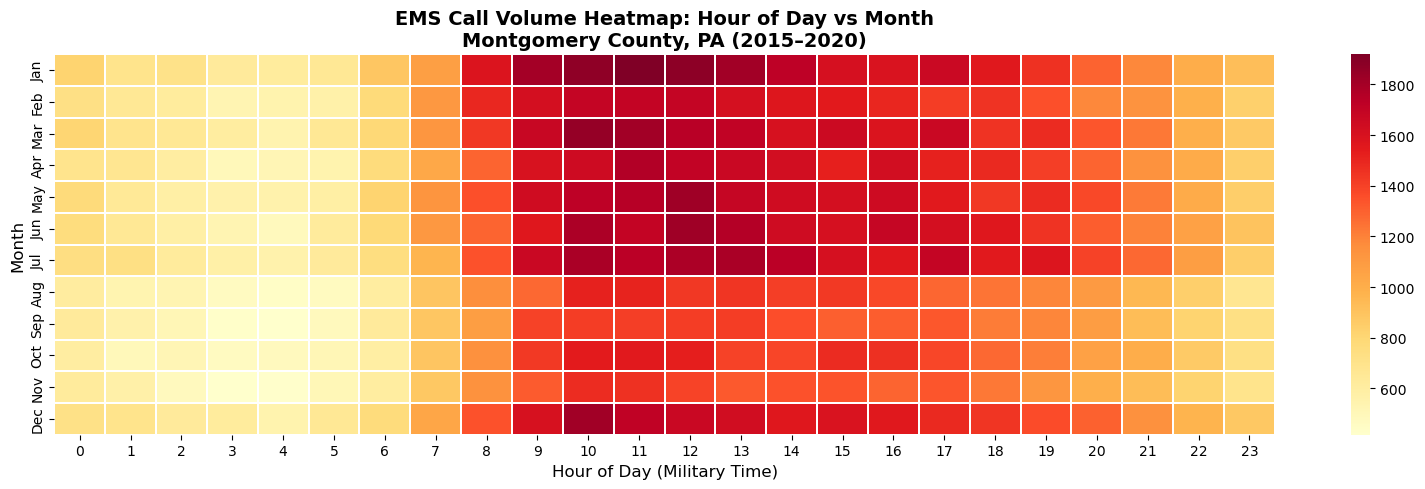

In [65]:
pivot = df.groupby(['month', 'hour']).size().unstack()
pivot.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3)
plt.title('EMS Call Volume Heatmap: Hour of Day vs Month\nMontgomery County, PA (2015–2020)',
          fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (Military Time)', fontsize=12)
plt.ylabel('Month', fontsize=12)
plt.tight_layout()
#plt.savefig('EMS_CV_Heatmap', dpi=150) # optional save, delete '#' in front to save.
plt.show()

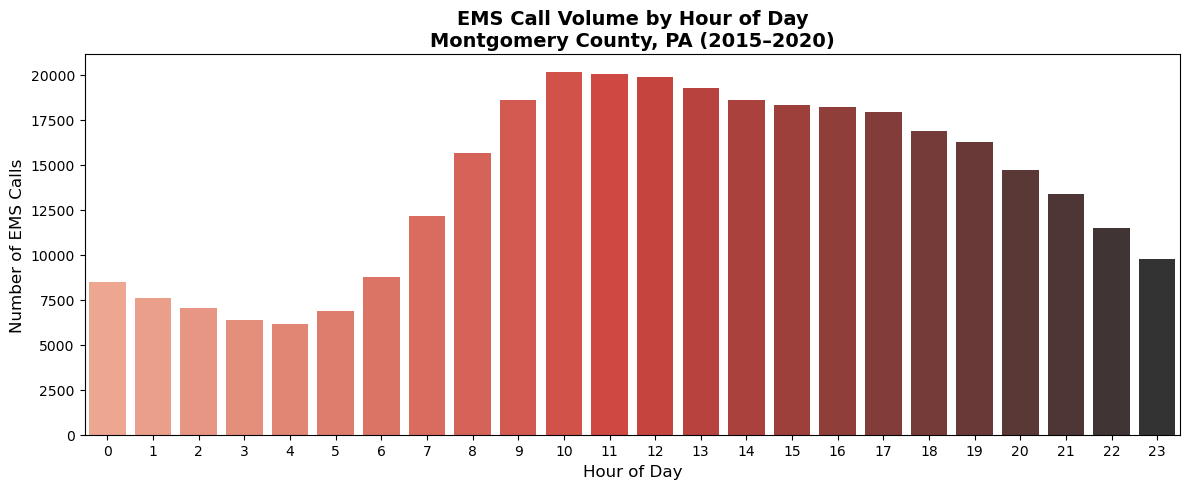

In [66]:
plt.figure(figsize=(12, 5))
sns.countplot(x='hour', data=df, hue='hour', palette='Reds_d', legend=False)
plt.title('EMS Call Volume by Hour of Day\nMontgomery County, PA (2015–2020)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Number of EMS Calls', fontsize=12)
plt.xticks(range(0, 24))
plt.tight_layout()
#plt.savefig('EMS_CV_Chart', dpi=150)  # optional save, delete '#' in front to save.
plt.show()

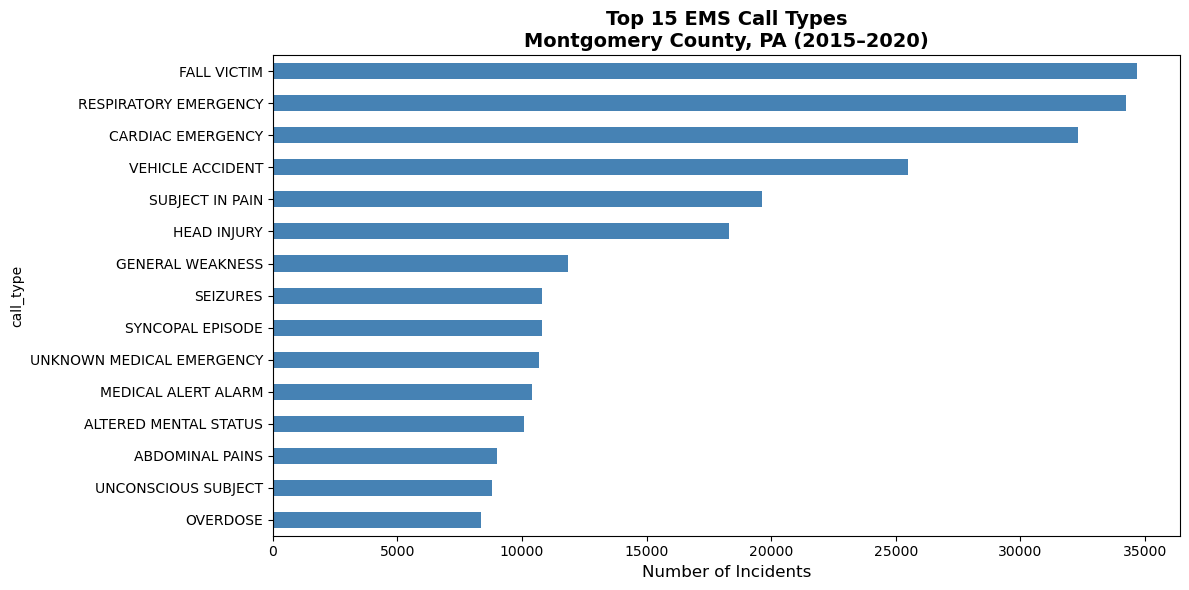

In [67]:
top_calls = df['call_type'].value_counts().head(15)

plt.figure(figsize=(12, 6))
top_calls.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 EMS Call Types\nMontgomery County, PA (2015–2020)',fontsize=14, fontweight='bold')
plt.xlabel('Number of Incidents', fontsize=12)
plt.tight_layout()
#plt.savefig('EMS_Top15_Chart', dpi=150)  # optional save, delete '#' in front to save.
plt.show()

### Step 5 (Target Variable Creation)
- Aggregate Calls
- Define and assign demand levels thresholds
  - Low (Less than 6 calls per hour in the entire county)
  - Medium (7 - 10)
  - High (10+)
- Merge data back into main dataset

In [68]:
# Aggregate calls per hour
df['date_hour'] = df['timeStamp'].dt.floor('h')
hourly_counts = df.groupby('date_hour').size().reset_index(name='call_count')

print("Hourly call count distribution:")
print(hourly_counts['call_count'].describe())

Hourly call count distribution:
count    40346.000000
mean         8.245972
std          4.221677
min          1.000000
25%          5.000000
50%          8.000000
75%         11.000000
max         31.000000
Name: call_count, dtype: float64


In [69]:
# Define thresholds
low_thresh = hourly_counts['call_count'].quantile(0.33)
high_thresh = hourly_counts['call_count'].quantile(0.66)

print(f'Low/Medium threshold: {low_thresh:.1f} calls/hour')
print(f'Medium/High threshold: {high_thresh:.1f} calls/hour')

# Assign Demand Levels
def classify_demand(count):
    if count <= low_thresh:
        return 'Low'
    elif count <= high_thresh:
        return 'Medium'
    else:
        return 'High'

hourly_counts['demand_level'] = hourly_counts['call_count'].apply(classify_demand)

# Print the Demand Level Distribution
print("\nDemand level distribution:")
print(hourly_counts['demand_level'].value_counts().to_string())

Low/Medium threshold: 6.0 calls/hour
Medium/High threshold: 10.0 calls/hour

Demand level distribution:
demand_level
Low       15513
Medium    13042
High      11791


In [70]:
# Merge Demand levels back into data
df = df.merge(hourly_counts[['date_hour', 'demand_level']], on='date_hour', how='left')

print(f'Demand levels assigned: {df["demand_level"].notna().sum():,} rows')
df[['timeStamp', 'hour', 'month', 'call_type', 'demand_level']].head()

Demand levels assigned: 332,692 rows


,timeStamp,hour,month,call_type,demand_level
0,2015-12-10 17:10:52,17,12,BACK PAINS/INJURY,Low
1,2015-12-10 17:29:21,17,12,DIABETIC EMERGENCY,Low
2,2015-12-10 16:47:36,16,12,CARDIAC EMERGENCY,Low
3,2015-12-10 16:56:52,16,12,DIZZINESS,Low
4,2015-12-10 15:39:04,15,12,HEAD INJURY,Low


### Step 6 (Train-Test Split and Models)
- Prepare features
- Prepare the train-test split
- train models
  - Baseline
  - Random Forest
  - XGBoost
- Comparison of Performance between all three


In [71]:
from sklearn.model_selection import train_test_split

feature_cols = (['hour', 'month'] + [c for c in df.columns if c.startswith('type_')])

X = df[feature_cols].fillna(0)
y = df['demand_level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Total samples: {len(X):,}')
print(f'Training samples: {len(X_train):,} (80%)')
print(f'Testing samples: {len(X_test):,} (20%)')
print(f'Feature count: {len(feature_cols)}')

Total samples: 332,692
Training samples: 266,153 (80%)
Testing samples: 66,539 (20%)
Feature count: 83


In [72]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("Random Forest Classifier trained successfully.")
print(f"Number of trees: {model.n_estimators}")

Random Forest Classifier trained successfully.
Number of trees: 100


### Step 7 (Results)
- Confusion Matrix
- Classification Results
- Baseline Comparisons
- Demand Levels based off Hours

In [73]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("CLASSIFICATION REPORT — EMS Demand Level Prediction")
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")

CLASSIFICATION REPORT — EMS Demand Level Prediction
              precision    recall  f1-score   support

         Low       0.65      0.85      0.74     31872
      Medium       0.66      0.58      0.62     12668
        High       0.47      0.30      0.36     21999

    accuracy                           0.62     66539
   macro avg       0.60      0.58      0.57     66539
weighted avg       0.60      0.62      0.59     66539

Overall Accuracy: 0.6172


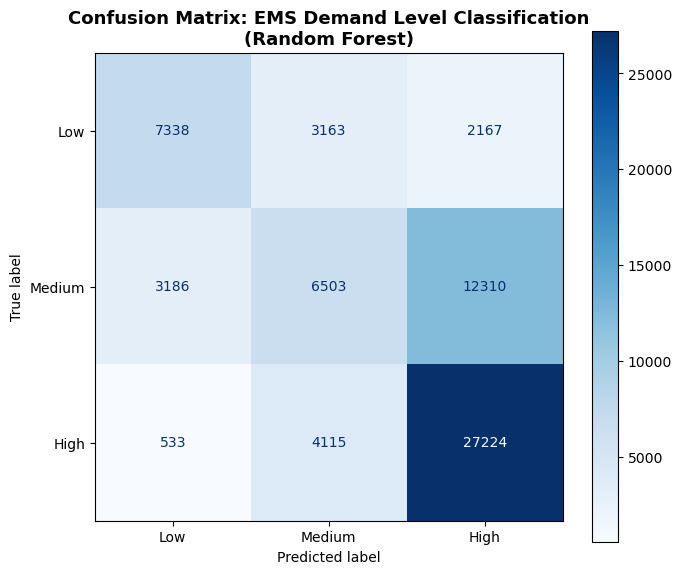

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix: EMS Demand Level Classification\n(Random Forest)', fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig('CM_Random_Forest', dpi=150) # optional save, delete '#' in front to save.
plt.show()


In [74]:
#Import and Encode Labels for XGBoost
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("Import Successful")

Import Successful


In [75]:
#XGBoost Training
xgb_model = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0)
xgb_model.fit(X_train, y_train_encoded)

print("XGBoost Classifier trained.")
print(f"Number of trees: {xgb_model.n_estimators}")

XGBoost Classifier trained.
Number of trees: 100


In [76]:
#XGBoost Classification Report
y_pred_xgb = xgb_model.predict(X_test)
y_pred_xgb_labels = le.inverse_transform(y_pred_xgb)

print("CLASSIFICATION REPORT: XGBoost")
print(classification_report(y_test, y_pred_xgb_labels, target_names=['Low', 'Medium', 'High']))
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_xgb_labels):.4f}")

CLASSIFICATION REPORT: XGBoost
              precision    recall  f1-score   support

         Low       0.66      0.87      0.75     31872
      Medium       0.67      0.61      0.64     12668
        High       0.49      0.29      0.36     21999

    accuracy                           0.63     66539
   macro avg       0.61      0.59      0.58     66539
weighted avg       0.61      0.63      0.60     66539

Overall Accuracy: 0.6276


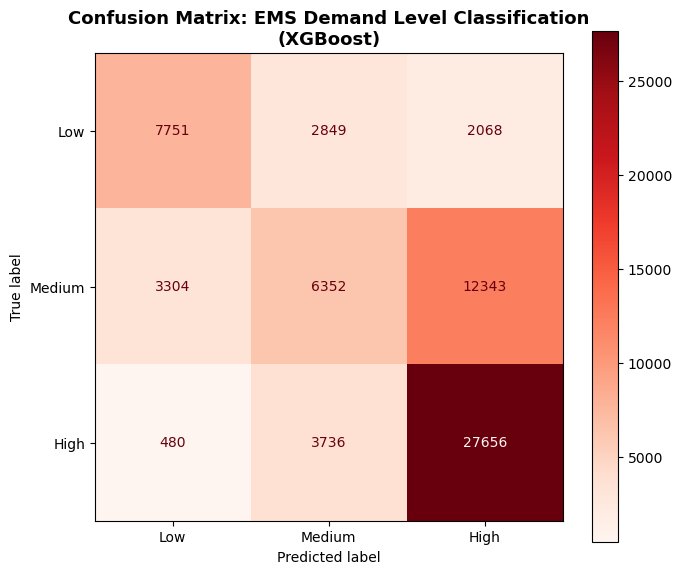

In [77]:
# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb_labels, labels=['Low', 'Medium', 'High'])
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb,display_labels=['Low', 'Medium', 'High'])

fig, ax = plt.subplots(figsize=(7, 6))
disp_xgb.plot(cmap='Reds', ax=ax)
ax.set_title('Confusion Matrix: EMS Demand Level Classification\n(XGBoost)', fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig('CM_XGBoost', dpi=150) # optional save, delete '#' in front to save.
plt.show()

In [78]:
xgb_acc = accuracy_score(y_test, y_pred_xgb_labels)
rf_acc = accuracy_score(y_test, y_pred)
baseline_acc_val = accuracy_score(y_test, baseline_pred)

print("Model Comparison Summary")
print("=" * 50)
print(f"Baseline accuracy: {baseline_acc_val:.4f} (47.9%)")
print(f"Random Forest accuracy: {rf_acc:.4f}")
print(f"XGBoost accuracy: {xgb_acc:.4f}")
print(f"\nRF improvement over baseline:  +{rf_acc - baseline_acc_val:.4f} ({((rf_acc - baseline_acc_val)/baseline_acc_val)*100:.1f}%)")
print(f"XGB improvement over baseline: +{xgb_acc - baseline_acc_val:.4f} ({((xgb_acc - baseline_acc_val)/baseline_acc_val)*100:.1f}%)")

Model Comparison Summary
Baseline accuracy: 0.4790 (47.9%)
Random Forest accuracy: 0.6172
XGBoost accuracy: 0.6276

RF improvement over baseline:  +0.1382 (28.8%)
XGB improvement over baseline: +0.1486 (31.0%)


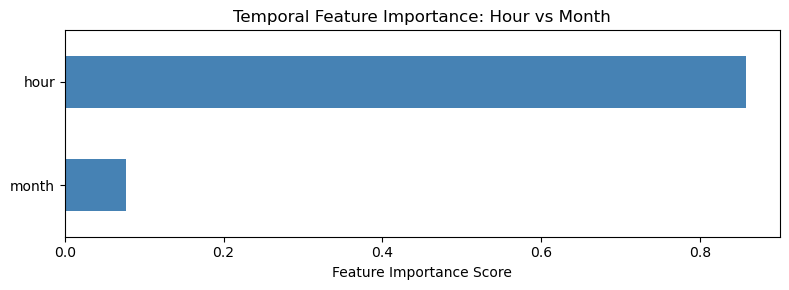

In [115]:
importances = pd.Series(model.feature_importances_, index=feature_cols)
time_features = importances[['hour', 'month']].sort_values()

time_features.plot(kind='barh', color='steelblue', figsize=(8, 3))
plt.title('Temporal Feature Importance: Hour vs Month')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
# plt.savefig('hour_vs_month', dpi=150) # optional save, delete '#' in front to save.
plt.show()

In [117]:
# Check average calls per hour across all months
print(df.groupby('hour')['demand_level'].value_counts(normalize=True).unstack())

demand_level      High       Low    Medium
hour                                      
0             0.074122  0.573593  0.352285
1             0.032826  0.673976  0.293199
2             0.024840  0.712562  0.262598
3             0.007245  0.804221  0.188534
4             0.012875  0.833768  0.153357
5             0.017396  0.754277  0.228327
6             0.059031  0.568547  0.372422
7             0.202061  0.267601  0.530338
8             0.470566  0.114609  0.414826
9             0.671989  0.046720  0.281290
10            0.764256  0.031293  0.204451
11            0.739552  0.026364  0.234084
12            0.738431  0.026107  0.235463
13            0.705363  0.039961  0.254677
14            0.655622  0.044141  0.300236
15            0.645571  0.051840  0.302589
16            0.625968  0.049102  0.324930
17            0.623518  0.056010  0.320472
18            0.550257  0.065136  0.384606
19            0.502087  0.091333  0.406580
20            0.398751  0.138233  0.463016
21         

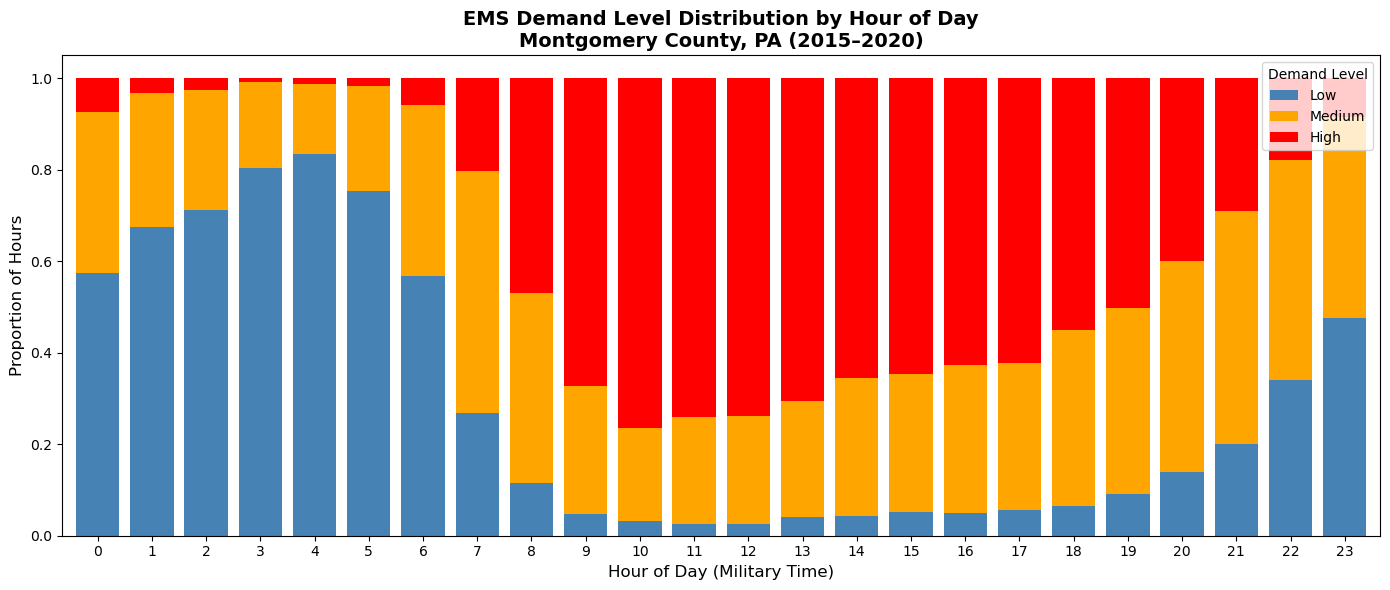

In [119]:
hour_demand = df.groupby('hour')['demand_level'].value_counts(normalize=True).unstack()
hour_demand = hour_demand[['Low', 'Medium', 'High']]

hour_demand.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 6),
    color=['steelblue', 'orange', 'red'],
    width=0.8
)

plt.title('EMS Demand Level Distribution by Hour of Day\nMontgomery County, PA (2015–2020)',
          fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (Military Time)', fontsize=12)
plt.ylabel('Proportion of Hours', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Demand Level', loc='upper right')
plt.tight_layout()
# plt.savefig('demand_by_hour', dpi=150) # optional save, delete '#' in front to save.
plt.show()

## Prediction Demo
1. Input an hour between 0 and 23.
2. Input a month between 1 and 12
3. The model will predict the demand level of EMS

In [110]:
# User input
while True:
    try:
        hour = int(input("Enter hour (0-23): "))
        if 0 <= hour <= 23:
            break
        else:
            print("Invalid input. Please enter a number between 0 and 23.")
    except ValueError:
        print("Invalid input. Please enter a whole number.")

while True:
    try:
        month = int(input("Enter month (1-12): "))
        if 1 <= month <= 12:
            break
        else:
            print("Invalid input. Please enter a number between 1 and 12.")
    except ValueError:
        print("Invalid input. Please enter a whole number.")
        
# Build sample
sample = pd.DataFrame(0, index=[0], columns=feature_cols)
sample['hour'] = hour
sample['month'] = month

# Predict
rf_pred  = model.predict(sample)[0]
xgb_pred = le.inverse_transform(xgb_model.predict(sample))[0]

print()
print("EMS DEMAND LEVEL PREDICTION")
print("=" * 45)
print(f"Hour:  {hour}:00")
print(f"Month: {month}")
print(f"\nRandom Forest: {rf_pred} Demand")
print(f"XGBoost: {xgb_pred} Demand")

Enter hour (0-23 military time):  24


Invalid input. Please enter a number between 0 and 23.


Enter hour (0-23 military time):  -1


Invalid input. Please enter a number between 0 and 23.


Enter hour (0-23 military time):  0
Enter month (1-12):  2



EMS DEMAND LEVEL PREDICTION
Hour:  0:00
Month: 2

Random Forest: Low Demand
XGBoost: Low Demand
